# Branch B : Disparity / Depth EDA

**Project:** CNN vs SNN for LiDAR–Event Camera Fusion  
**Course:** ECE 5424 Advanced Machine Learning — Virginia Tech Spring 2026  
**Dataset:** DSEC `zurich_city_04_a` — disparity event frames (`disparity_event/`)  

---

## Architecture context

```
Branch B (Depth/Disparity)
  disparity_event/ PNGs  →  visualise + analyse  →  BEV projection  →  3-layer CNN
```

DSEC provides dense **disparity maps** aligned to the event camera timeline.  
They are stored as **uint16 in Q8.8 fixed-point format**. Divide by 256 to obtain disparity in pixels.

Depth conversion: $Z = \dfrac{f \cdot B}{d}$ where  
- $f$ = 569.3 px (rectified focal length from `cam_to_cam.yaml`)  
- $B$ = 43.7 mm (stereo baseline)  
- $d$ = disparity in pixels  

> **Convention:** higher disparity = closer object (standard stereo geometry).

## 0. Imports & path configuration

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from pathlib import Path
from tqdm.notebook import tqdm

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

# Paths (adjust DATA_ROOT if your DSEC folder is elsewhere)
import sys
sys.path.append("..")
from config import DATA_ROOT

SCENE       = "zurich_city_04_a"
DISP_DIR    = os.path.join(DATA_ROOT, SCENE, f"{SCENE}_disparity_event")
CALIB_DIR   = os.path.join(DATA_ROOT, SCENE, f"{SCENE}_calibration")
FIGURES_DIR = os.path.join("..", "docs", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

# DSEC Q8.8 encoding
DISP_SCALE  = 256.0    # divide raw uint16 by this → disparity in pixels

# Stereo params from cam_to_cam.yaml (rectified)
FOCAL_PX    = 569.2873535700672   # px
BASELINE_M  = 0.043722240320426424  # metres

frames = sorted(Path(DISP_DIR).glob("*.png"))
print(f"Disparity frames found : {len(frames)}")
print(f"First frame            : {frames[0].name}")
print(f"Last  frame            : {frames[-1].name}")

Disparity frames found : 351
First frame            : 000000.png
Last  frame            : 000700.png


## 1. Inspect a single frame

Shape  : (480, 640)
dtype  : uint16
Raw range  : [0, 19096]
Disp range : [0.00, 74.59] px
Valid pixels (disp > 0): 76,726 / 307,200  (25.0%)


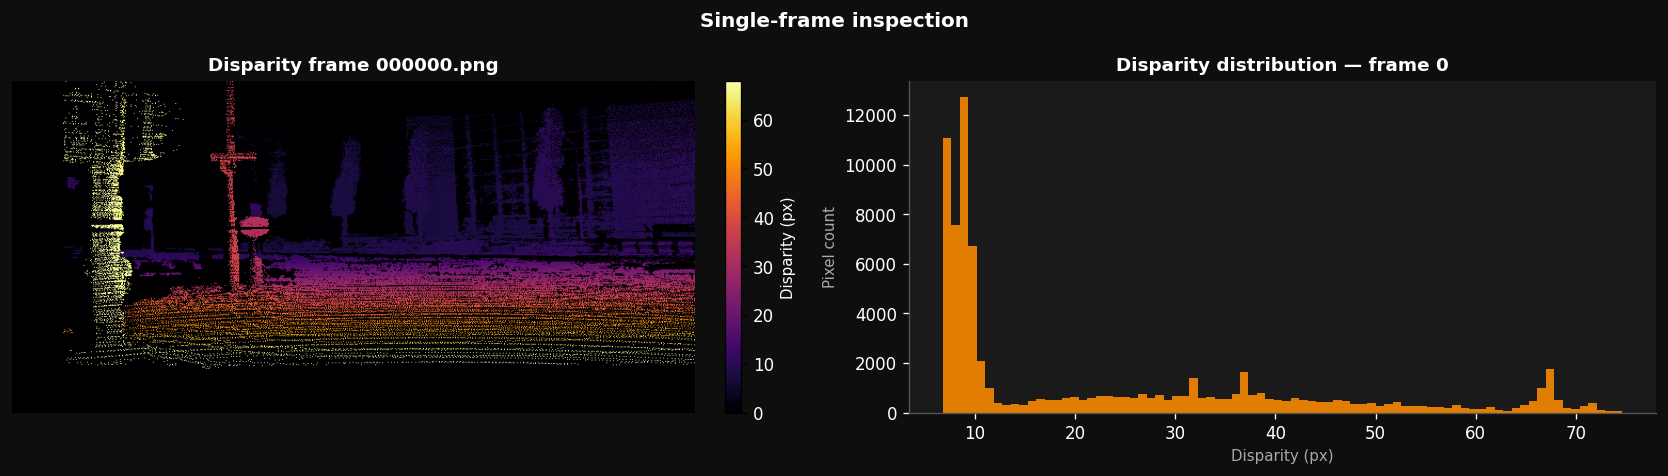

In [2]:
raw0  = np.array(Image.open(frames[0]))
disp0 = raw0.astype(np.float32) / DISP_SCALE

print(f"Shape  : {raw0.shape}")
print(f"dtype  : {raw0.dtype}")
print(f"Raw range  : [{raw0.min()}, {raw0.max()}]")
print(f"Disp range : [{disp0.min():.2f}, {disp0.max():.2f}] px")
print(f"Valid pixels (disp > 0): {(disp0 > 0).sum():,} / {disp0.size:,}  "
      f"({(disp0>0).mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.patch.set_facecolor('#0e0e0e')

vm = np.percentile(disp0[disp0>0], 98)
im0 = axes[0].imshow(disp0, cmap='inferno', vmin=0, vmax=vm, aspect='auto')
axes[0].set_title('Disparity frame 000000.png', color='white', fontsize=11, fontweight='bold')
axes[0].axis('off')
cb = fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
cb.set_label('Disparity (px)', color='white', fontsize=9)
[t.set_color('white') for t in cb.ax.get_yticklabels()]

valid_disp = disp0[disp0 > 0]
axes[1].set_facecolor('#1a1a1a')
axes[1].hist(valid_disp, bins=80, color='#ff8c00', edgecolor='none', alpha=0.88)
axes[1].set_title('Disparity distribution — frame 0', color='white', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Disparity (px)', color='#aaa', fontsize=9)
axes[1].set_ylabel('Pixel count',   color='#aaa', fontsize=9)
axes[1].tick_params(colors='white')
for sp in ['top','right']: axes[1].spines[sp].set_visible(False)
for sp in ['bottom','left']: axes[1].spines[sp].set_color('#555')

fig.suptitle('Single-frame inspection', color='white', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Load all frames:  global statistics

We aggregate valid (non-zero) disparity values across all 351 frames.

In [3]:
all_disp = []
n_frames = len(frames)

for fp in tqdm(frames, desc="Loading disparity frames"):
    raw  = np.array(Image.open(fp)).astype(np.float32)
    disp = raw / DISP_SCALE
    valid = disp[disp > 0]
    if len(valid):
        all_disp.append(valid)

all_disp = np.concatenate(all_disp)

# Depth conversion
all_depth = FOCAL_PX * BASELINE_M / all_disp.clip(min=0.5)

print(f"Total valid disparity samples : {len(all_disp):,}")
print()
print("Disparity statistics (px):")
for label, val in [
    ("  Min   ", all_disp.min()),
    ("  Max   ", all_disp.max()),
    ("  Mean  ", all_disp.mean()),
    ("  Median", np.median(all_disp)),
    ("  Std   ", all_disp.std()),
    ("  1st % ", np.percentile(all_disp,  1)),
    ("  25th %", np.percentile(all_disp, 25)),
    ("  75th %", np.percentile(all_disp, 75)),
    ("  99th %", np.percentile(all_disp, 99)),
]:
    print(f"{label} : {val:.2f} px")

Loading disparity frames:   0%|          | 0/351 [00:00<?, ?it/s]

Total valid disparity samples : 27,944,148

Disparity statistics (px):
  Min    : 6.82 px
  Max    : 75.01 px
  Mean   : 21.36 px
  Median : 16.41 px
  Std    : 13.95 px
  1st %  : 7.01 px
  25th % : 10.77 px
  75th % : 28.13 px
  99th % : 66.75 px


## 3. Five-frame spatial survey + distribution plots

We select frames evenly spaced across the sequence to check temporal consistency of the disparity signal.

Figure saved → ..\docs\figures\disparity_example.png


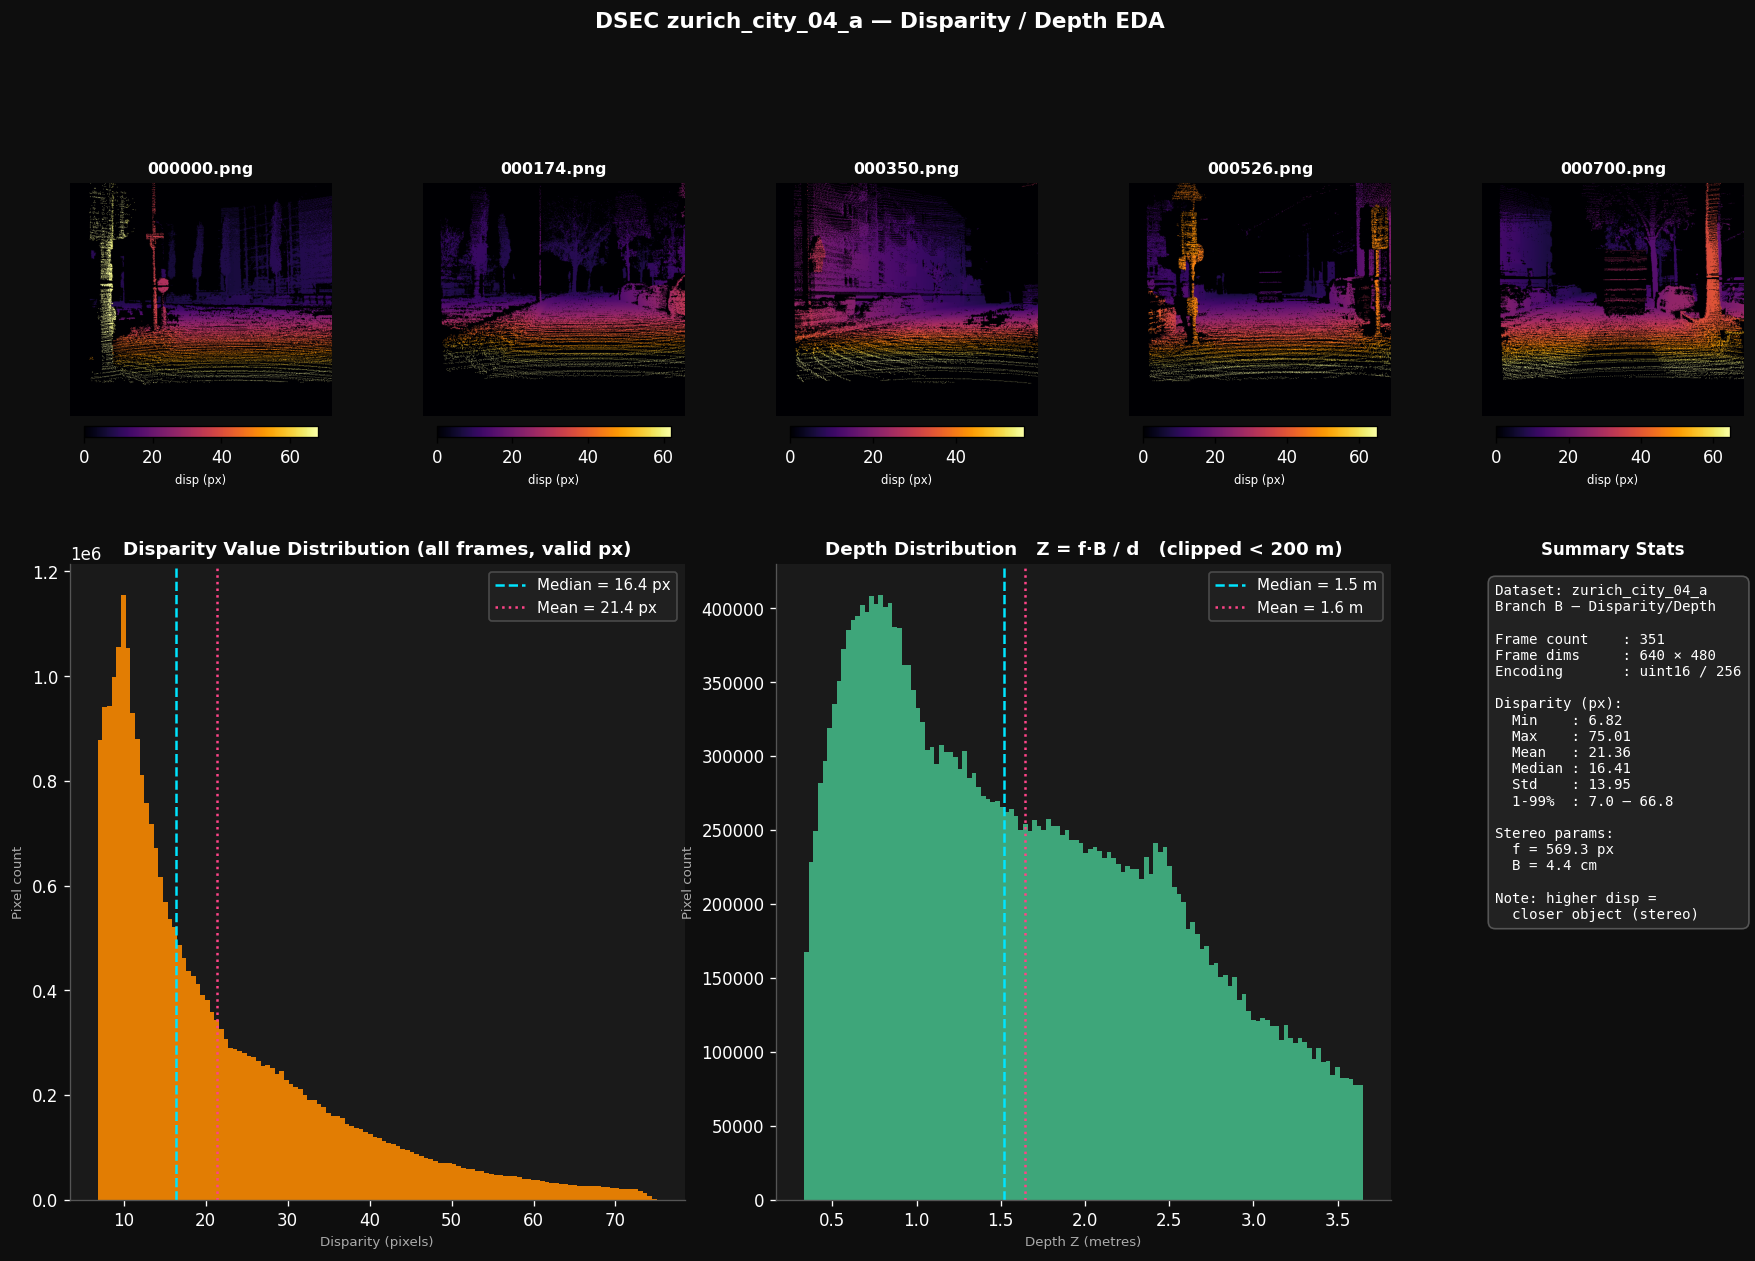

In [5]:
sample_indices = [0, n_frames//4, n_frames//2, 3*n_frames//4, n_frames-1]
sample_frames  = []
for i in sample_indices:
    raw  = np.array(Image.open(frames[i])).astype(np.float32)
    disp = raw / DISP_SCALE
    sample_frames.append((i, frames[i].name, disp))

fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor('#0e0e0e')
gs  = gridspec.GridSpec(3, 5, figure=fig, hspace=0.5, wspace=0.35)

title_kw = dict(color='white', fontsize=9.5, fontweight='bold', pad=6)
label_kw = dict(color='#aaaaaa', fontsize=8)

# Row 0 : five sample frames
for col, (fi, fname, disp) in enumerate(sample_frames):
    ax = fig.add_subplot(gs[0, col])
    vm = np.percentile(disp[disp>0], 98) if (disp>0).any() else 1
    im = ax.imshow(disp, cmap='inferno', vmin=0, vmax=vm, aspect='auto')
    ax.set_title(fname, **title_kw)
    ax.axis('off')
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, orientation='horizontal')
    cb.set_label('disp (px)', color='white', fontsize=7)
    [t.set_color('white') for t in cb.ax.get_xticklabels()]

# Disparity histogram
ax_dh = fig.add_subplot(gs[1:, :2])
ax_dh.set_facecolor('#1a1a1a')
ax_dh.hist(all_disp, bins=120, color='#ff8c00', edgecolor='none', alpha=0.88)
ax_dh.axvline(np.median(all_disp), color='#00e5ff', lw=1.5, ls='--',
              label=f'Median = {np.median(all_disp):.1f} px')
ax_dh.axvline(all_disp.mean(), color='#ff4488', lw=1.5, ls=':',
              label=f'Mean = {all_disp.mean():.1f} px')
ax_dh.set_title('Disparity Value Distribution (all frames, valid px)',
                color='white', fontsize=11, fontweight='bold')
ax_dh.set_xlabel('Disparity (pixels)', **label_kw)
ax_dh.set_ylabel('Pixel count',         **label_kw)
ax_dh.tick_params(colors='white')
for sp in ['bottom','left']: ax_dh.spines[sp].set_color('#555')
for sp in ['top','right']:   ax_dh.spines[sp].set_visible(False)
leg = ax_dh.legend(fontsize=9, facecolor='#222', edgecolor='#555')
for t in leg.get_texts(): t.set_color('white')

# Depth histogram (depth = f*B/d)
ax_dp = fig.add_subplot(gs[1:, 2:4])
ax_dp.set_facecolor('#1a1a1a')
depth_vis = all_depth[all_depth < 200]   # clip extreme tails
ax_dp.hist(depth_vis, bins=120, color='#44bb88', edgecolor='none', alpha=0.88)
ax_dp.axvline(np.median(depth_vis), color='#00e5ff', lw=1.5, ls='--',
              label=f'Median = {np.median(depth_vis):.1f} m')
ax_dp.axvline(depth_vis.mean(), color='#ff4488', lw=1.5, ls=':',
              label=f'Mean = {depth_vis.mean():.1f} m')
ax_dp.set_title('Depth Distribution   Z = f·B / d   (clipped < 200 m)',
                color='white', fontsize=11, fontweight='bold')
ax_dp.set_xlabel('Depth Z (metres)', **label_kw)
ax_dp.set_ylabel('Pixel count',       **label_kw)
ax_dp.tick_params(colors='white')
for sp in ['bottom','left']: ax_dp.spines[sp].set_color('#555')
for sp in ['top','right']:   ax_dp.spines[sp].set_visible(False)
leg2 = ax_dp.legend(fontsize=9, facecolor='#222', edgecolor='#555')
for t in leg2.get_texts(): t.set_color('white')

# Stats panel
ax_st = fig.add_subplot(gs[1:, 4])
ax_st.set_facecolor('#1a1a1a'); ax_st.axis('off')
p1, p99 = np.percentile(all_disp, [1, 99])
txt = (
    f"Dataset: zurich_city_04_a\n"
    f"Branch B — Disparity/Depth\n\n"
    f"Frame count    : {n_frames}\n"
    f"Frame dims     : 640 × 480\n"
    f"Encoding       : uint16 / 256\n\n"
    f"Disparity (px):\n"
    f"  Min    : {all_disp.min():.2f}\n"
    f"  Max    : {all_disp.max():.2f}\n"
    f"  Mean   : {all_disp.mean():.2f}\n"
    f"  Median : {np.median(all_disp):.2f}\n"
    f"  Std    : {all_disp.std():.2f}\n"
    f"  1-99%  : {p1:.1f} – {p99:.1f}\n\n"
    f"Stereo params:\n"
    f"  f = {FOCAL_PX:.1f} px\n"
    f"  B = {BASELINE_M*100:.1f} cm\n\n"
    f"Note: higher disp =\n"
    f"  closer object (stereo)"
)
ax_st.text(0.05, 0.97, txt, transform=ax_st.transAxes, fontsize=8.5,
           va='top', color='white', fontfamily='monospace',
           bbox=dict(boxstyle='round,pad=0.5', facecolor='#222', edgecolor='#555'))
ax_st.set_title('Summary Stats', color='white', fontsize=10, fontweight='bold')

fig.suptitle(
    'DSEC zurich_city_04_a — Disparity / Depth EDA\n',
    color='white', fontsize=13, fontweight='bold', y=1.01
)

SAVE_PATH = os.path.join(FIGURES_DIR, "disparity_example.png")
plt.savefig(SAVE_PATH, dpi=150, bbox_inches='tight', facecolor='#0e0e0e')
print(f"Figure saved → {SAVE_PATH}")
plt.show()

## 4. Temporal consistency check

Plot mean and std of valid disparity per frame to verify the sensor is stable across the sequence.

Temporal stats:   0%|          | 0/351 [00:00<?, ?it/s]

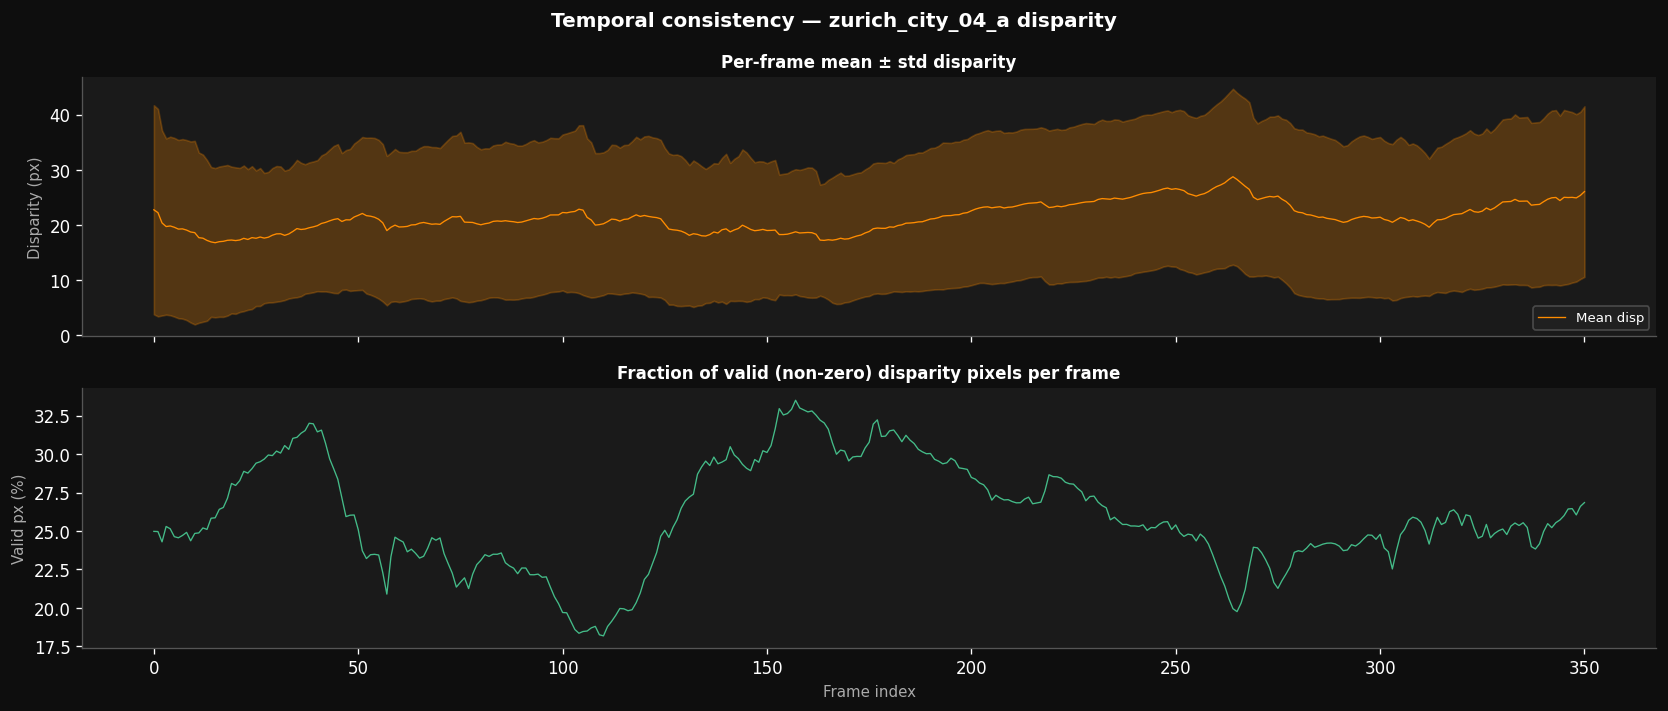

Mean disparity over sequence : 21.50 ± 2.58 px
Mean valid fraction          : 25.9%


In [6]:
means, stds, valid_fracs = [], [], []

for fp in tqdm(frames, desc="Temporal stats"):
    d = np.array(Image.open(fp)).astype(np.float32) / DISP_SCALE
    v = d[d > 0]
    means.append(v.mean() if len(v) else 0)
    stds.append(v.std()   if len(v) else 0)
    valid_fracs.append(len(v) / d.size)

means = np.array(means); stds = np.array(stds); valid_fracs = np.array(valid_fracs)
frame_ids = np.arange(n_frames)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
fig.patch.set_facecolor('#0e0e0e')

for ax in axes:
    ax.set_facecolor('#1a1a1a')
    ax.tick_params(colors='white')
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    for sp in ['bottom','left']: ax.spines[sp].set_color('#555')

axes[0].plot(frame_ids, means, color='#ff8c00', lw=0.8, label='Mean disp')
axes[0].fill_between(frame_ids, means-stds, means+stds, alpha=0.25, color='#ff8c00')
axes[0].set_ylabel('Disparity (px)', color='#aaa', fontsize=9)
axes[0].set_title('Per-frame mean ± std disparity', color='white', fontsize=10, fontweight='bold')
leg = axes[0].legend(fontsize=8, facecolor='#222', edgecolor='#555')
for t in leg.get_texts(): t.set_color('white')

axes[1].plot(frame_ids, valid_fracs * 100, color='#44bb88', lw=0.8)
axes[1].set_ylabel('Valid px (%)', color='#aaa', fontsize=9)
axes[1].set_xlabel('Frame index',  color='#aaa', fontsize=9)
axes[1].set_title('Fraction of valid (non-zero) disparity pixels per frame',
                   color='white', fontsize=10, fontweight='bold')

fig.suptitle('Temporal consistency — zurich_city_04_a disparity',
             color='white', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Mean disparity over sequence : {means.mean():.2f} ± {means.std():.2f} px")
print(f"Mean valid fraction          : {valid_fracs.mean()*100:.1f}%")

## 5. Summary stats for Milestone Report

In [7]:
print("━" * 55)
print(" MILESTONE REPORT — Disparity/Depth EDA Summary")
print("━" * 55)
print(f"  Dataset            : DSEC zurich_city_04_a")
print(f"  Disparity frames   : {n_frames}")
print(f"  Frame resolution   : 640 × 480 px")
print(f"  Encoding           : uint16 Q8.8  (÷ 256 → px)")
print(f"  Disparity min      : {all_disp.min():.2f} px")
print(f"  Disparity max      : {all_disp.max():.2f} px")
print(f"  Disparity mean     : {all_disp.mean():.2f} px")
print(f"  Disparity median   : {np.median(all_disp):.2f} px")
print(f"  Disparity std      : {all_disp.std():.2f} px")
print(f"  Valid px fraction  : {valid_fracs.mean()*100:.1f}%  (avg per frame)")
print(f"  Focal length       : {FOCAL_PX:.1f} px")
print(f"  Baseline           : {BASELINE_M*1000:.1f} mm")
print("━" * 55)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 MILESTONE REPORT — Disparity/Depth EDA Summary
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Dataset            : DSEC zurich_city_04_a
  Disparity frames   : 351
  Frame resolution   : 640 × 480 px
  Encoding           : uint16 Q8.8  (÷ 256 → px)
  Disparity min      : 6.82 px
  Disparity max      : 75.01 px
  Disparity mean     : 21.36 px
  Disparity median   : 16.41 px
  Disparity std      : 13.95 px
  Valid px fraction  : 25.9%  (avg per frame)
  Focal length       : 569.3 px
  Baseline           : 43.7 mm
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
